# Descriptives, Norms, & Inter-Individual Differences
Sample descriptives, refusal rates, OCEAN score distributions, and normality tests.

In [1]:
import warnings
from src.reading_data import create_final_dfs
from src.visualizations import *

warnings.filterwarnings("ignore", category=UserWarning)
os.makedirs("../../doc/figs", exist_ok=True)
apply_paper_style()

In [2]:
# Load data
df_all_raw, _, _, _, _, df_metadata, _ = create_final_dfs()


Models excluded (< 200 valid responses), 17 total:
                                       n_valid
model                                         
ThingAI/Quark-270m-Base                      0
google/gemma-3-270m                         14
google/gemma-3-270m-it                      16
EssentialAI/rnj-1                           63
google/gemma-4-31B                          81
Qwen/Qwen3-0.6B                             93
Qwen/Qwen3.5-0.8B-Base                      99
google/gemma-3-1b-pt                       112
ThingAI/Quark-270m-Instruct                121
google/gemma-3-1b-it                       122
google/gemma-2b                            157
mistralai/Mistral-Small-24B-Base-2501      163
Qwen/Qwen3.5-4B-Base                       174
tiiuae/Falcon3-1B-Base                     178
Qwen/Qwen3.5-2B-Base                       192
allenai/OLMo-2-0425-1B                     197
google/gemma-2-2b                          198

Models present before exclusion: 264
Models remaining 

In [3]:
# Sanity check: Are any models missing?
meta = pd.read_csv("../../dat/03_large_scale_administration/meta_info_models.csv")

models_only_in_meta = set(meta["Model_ID"]) - set(df_all_raw["model"])
models_only_in_df_B = set(df_all_raw["model"].unique()) - set(meta["Model_ID"])

print("In meta but not df_B:")
print(models_only_in_meta)

print("\nIn df but not meta:")
print(models_only_in_df_B)

In meta but not df_B:
set()

In df but not meta:
set()


## Descriptive Statistics

In [4]:
stats, OCEAN_means = sample_desc(df_all_raw, df_metadata, OCEAN_COLS)

In [5]:
print("=== SAMPLE SIZE ===")
print(f"N models collected: {stats['n_models_collected']:,}")
print(f"N models valid: {stats['n_models_valid']}")
print(f"N models excluded: {stats['n_models_collected'] - stats['n_models_valid']}")

=== SAMPLE SIZE ===
N models collected: 264
N models valid: 247
N models excluded: 17


In [6]:
print("=== MODEL FAMILIES ===")
print(f"\nN model families: {len(stats['families_vals'])}")
print(f"Families: {stats['families_vals']}")

=== MODEL FAMILIES ===

N model families: 50
Families: <StringArray>
[      'qwen',       'olmo',     'claude',       'seed',   'mythomax',
    'minimax',     'hermes',         'l3',       'mimo',   'deepseek',
     'gemini',      'gemma',      'llama',        'phi',    'mistral',
       'kimi',   'nemotron',    'gpt-oss',       'step',        'glm',
        'gpt',    'granite',   'o-series',       'aion',       'nova',
    'trinity',      'ernie',    'ui tars',    'command',     'cogito',
        'rnj',    'mercury',       'ling',        'kat',        'lfm',
     'weaver',      'morph',        'owl',      'sonar',  'intellect',
       'reka',     'relace',     'router',    'hunyuan',        'hy3',
   'rocinate', 'unslopnemo',       'remm',     'falcon',       'grok']
Length: 50, dtype: str


In [7]:
print("=== REGIONS ===")
print(stats['regions'].to_string())
for country, fams in stats['country_family'].items():
    print(f"\n{country}:")
    for f in fams:
        print(f"  - {f}")

=== REGIONS ===
Region
US       113
china     97
EU        25
other      9
uae        3

EU:
  - mistral

US:
  - gpt
  - llama
  - gemma
  - grok
  - claude
  - gemini
  - olmo
  - nemotron
  - o-series
  - gpt-oss
  - granite
  - trinity
  - hermes
  - phi
  - mythomax
  - nova
  - cogito
  - rnj
  - mercury
  - lfm
  - weaver
  - owl
  - sonar
  - intellect
  - reka
  - relace
  - router
  - remm

china:
  - qwen
  - glm
  - deepseek
  - seed
  - minimax
  - kimi
  - mimo
  - ernie
  - step
  - ui tars
  - ling
  - hunyuan
  - hy3

other:
  - l3
  - morph
  - aion
  - command
  - kat
  - rocinate
  - unslopnemo

uae:
  - falcon


In [8]:
print("=== LICENSE GROUPS ===")
print(stats['licenses'].to_string())

=== LICENSE GROUPS ===
license_group
open-weight    138
proprietary    109


In [9]:
print("=== REASONING ===")
print(stats['reasoning_counts'].to_string())

=== REASONING ===
Reasoning
false    155
true      92


In [10]:
print("=== RELEASE DATES ===")
print(f"{stats['min_release'].date()} to {stats['max_release'].date()}")

=== RELEASE DATES ===
2023-07-02 to 2026-04-30


In [11]:
print("=== PARAMETERS ===")
print(f"{stats['min_params']:.2f}B to {stats['max_params']:.2f}B")

=== PARAMETERS ===
0.60B to 1020.00B


In [12]:
print("=== NUMBER RESPONSES & REFUSALS ===")

print(f"\nTotal responses (OCEAN): {stats['total_rows_OCEAN']:,}")
print(f"Valid responses (OCEAN): {stats['n_valid_OCEAN']:,}")
print(f"Invalid / refusal responses (OCEAN): {stats['n_invalid_OCEAN']:,}")

print(f"\nCompletion rate (OCEAN): {stats['completion_rate_OCEAN']:.2f}%")
print(f"Refusal rate (OCEAN): {stats['refusal_rate_OCEAN']:.2f}%")

print("\n\n=====\n\n")

print("\nTop 20 models with highest refusal rates (in %):")
print(
    stats['model_refusal']["refusal_rate"]
    .sort_values(ascending=False)
    .head(20)
    .round(2)
    .to_string()
)

=== NUMBER RESPONSES & REFUSALS ===

Total responses (OCEAN): 116,152
Valid responses (OCEAN): 104,326
Invalid / refusal responses (OCEAN): 11,826

Completion rate (OCEAN): 89.82%
Refusal rate (OCEAN): 10.18%


=====



Top 20 models with highest refusal rates (in %):
model
ThingAI/Quark-270m-Base                  100.00
google/gemma-3-270m                       97.50
google/gemma-3-270m-it                    97.27
EssentialAI/rnj-1                         88.41
google/gemma-4-31B                        86.14
Qwen/Qwen3-0.6B                           85.68
Qwen/Qwen3.5-0.8B-Base                    81.82
google/gemma-3-1b-pt                      81.14
ThingAI/Quark-270m-Instruct               78.64
google/gemma-3-1b-it                      77.95
google/gemma-2b                           73.18
Qwen/Qwen3.5-4B-Base                      72.73
mistralai/Mistral-Small-24B-Base-2501     72.73
Qwen/Qwen3.5-2B-Base                      68.41
tiiuae/Falcon3-1B-Base                    68.41
googl

In [13]:
print("=== MEAN BIG FIVE ===")
print(OCEAN_means.iloc[:5].round(2).to_string())

=== MEAN BIG FIVE ===
                   Mean    SD   Min    Q1  Median    Q3   Max
Openness           3.74  0.58  1.80  3.43    3.83  4.11  4.76
Conscientiousness  4.06  0.57  2.69  3.66    4.24  4.54  4.99
Extraversion       3.67  0.45  2.45  3.41    3.70  3.98  4.95
Agreeableness      4.03  0.52  2.50  3.64    4.24  4.42  4.74
Neuroticism        2.07  0.58  1.09  1.62    1.94  2.50  3.95


## Normality Tests (Kolmogorov–Smirnov)

In [14]:
### KS NORMALITY TESTS
ks_results = ks_normality_tests(df_metadata, cols=OCEAN_COLS)

print("=== Kolmogorov–Smirnov Normality Tests ===")
print(ks_results.to_string(index=False))

=== Kolmogorov–Smirnov Normality Tests ===
            trait     D     p interpretation
         Openness 0.092 0.029     non-normal
Conscientiousness 0.136 0.000     non-normal
     Extraversion 0.041 0.794 approx. normal
    Agreeableness 0.176 0.000     non-normal
      Neuroticism 0.105 0.008     non-normal


## OCEAN Score Distributions All Models
Boxplot (with human BFI baseline), histogram + KDE per trait.

N = 247


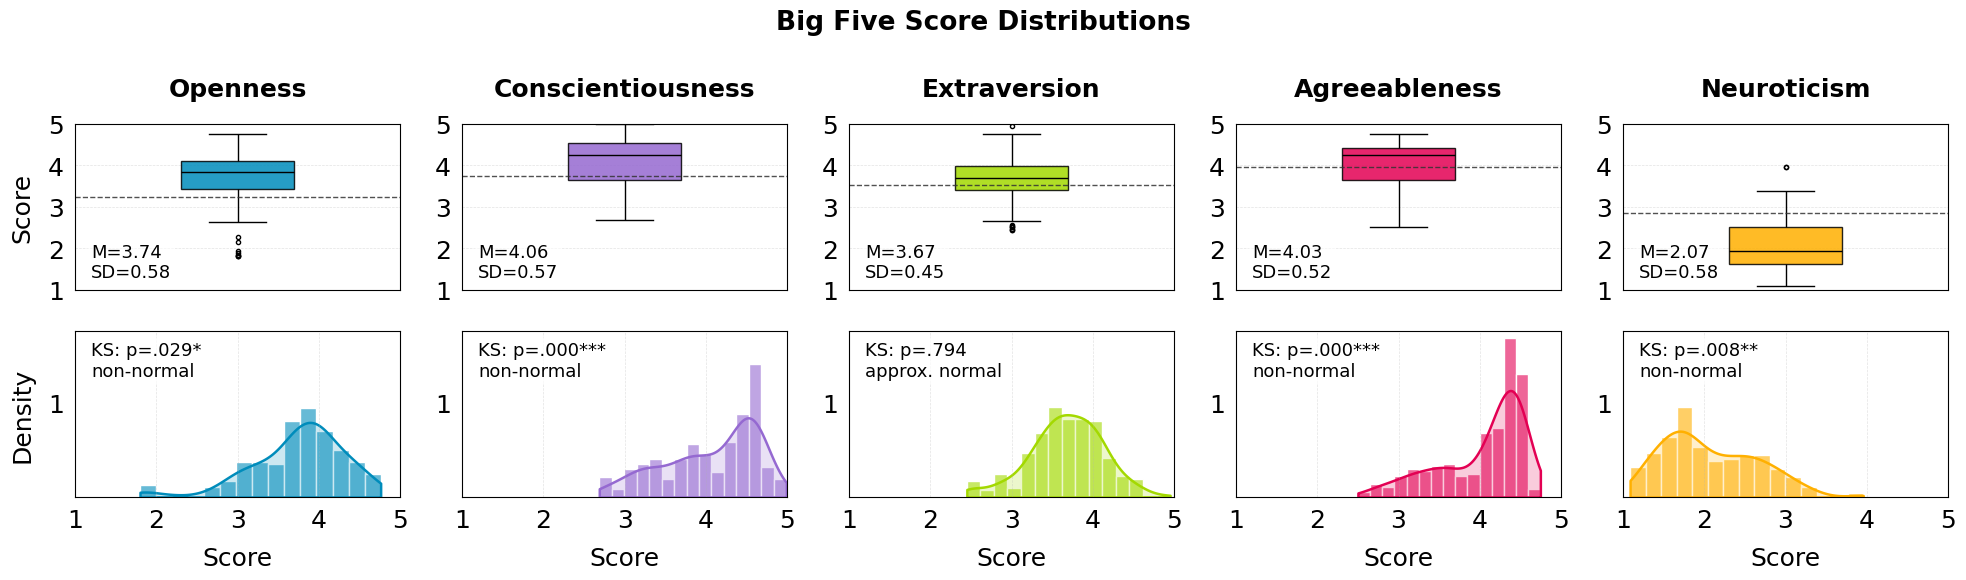

In [15]:
### DISTRIBUTION FIGURE (RQ2)
fig = plot_ocean_distributions(
    df_metadata,
    cols=OCEAN_COLS,
    title="Big Five Score Distributions",
    save_path="../../doc/figs/fig_ocean_all_models.pdf",
)
plt.show()